# Resource perspective

Resource-drift exploration for `data/resource.xes`, one section per drift type in the
log. Resource drifts change *who* does the work and *how fast*: **reassignment**
(which resource does each activity), **duration** (per-resource speed), **pool_size**
(how many resources are active), and **workload** (case volume). Drift points come
from `rheon:metadata`; the full ground truth lives in `data/resource_meta.md`.

In [10]:
import json
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import to_hex

import pm4py

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


root = Path.cwd()
if not (root / "data").exists():
    root = root.parent
log_path = root / "data" / "resource.xes"
WINDOW_DAYS = 30


def read_drifts(xes_path, perspective):
    """Drift records from the log's rheon:metadata, normalised to start/end timestamps."""
    ns = "{http://www.xes-standard.org/}"
    meta = {}
    for ev, el in ET.iterparse(str(xes_path), events=("start", "end")):
        if ev == "end" and el.tag == f"{ns}string" and el.attrib.get("key") == "rheon:metadata":
            meta = json.loads(el.attrib["value"])
            break
        if ev == "start" and el.tag == f"{ns}trace":
            break
    rows = []
    for d in meta.get("drifts", []):
        if d["perspective"] != perspective:
            continue
        point = d.get("drift_point_date")
        rows.append({
            "id": d["id"], "type": d["type"], "mode": d["mode"],
            "start": pd.Timestamp(point or d["drift_start_date"]),
            "end": pd.Timestamp(point or d["drift_end_date"]),
            "changes": d.get("changes") or {},
        })
    return pd.DataFrame(rows)


def mark_drifts(ax, rows, color="black"):
    """Vertical line at each drift (shaded band for gradual ones), labelled by id."""
    ymax = ax.get_ylim()[1]
    for d in rows.itertuples():
        if d.mode == "gradual":
            ax.axvspan(d.start, d.end, color=color, alpha=0.08)
        ax.axvline(d.start, color=color, ls="--", lw=1.0, alpha=0.8)
        ax.text(d.start, ymax, d.id, ha="center", va="bottom", fontsize=8,
                bbox=dict(facecolor="white", edgecolor=color, boxstyle="round,pad=0.15"))


drifts = read_drifts(log_path, "resource")
drifts[["id", "type", "mode", "start"]]

,id,type,mode,start
0,d01,reassignment,sudden,2020-06-17 00:16:26.225460+00:00
1,d02,duration,sudden,2020-12-02 00:32:52.450921+00:00
2,d03,workload,sudden,2021-11-03 01:05:44.901842+00:00


In [11]:
df = pm4py.read_xes(str(log_path)).rename(columns={
    "case:concept:name": "case_id",
    "concept:name": "activity",
    "time:timestamp": "timestamp",
    "org:resource": "resource",
})
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["start_timestamp"] = pd.to_datetime(df["start_timestamp"], utc=True)
df = df.sort_values(["case_id", "timestamp"]).reset_index(drop=True)
# week bucket (tz dropped so weekly aggregates read in plain UTC wall time)
df["week"] = df["timestamp"].dt.tz_localize(None).dt.to_period("W").dt.start_time
df["duration"] = df["event:duration_min"]
# wait = gap from the previous event's end to this event's start, within a case
df["wait"] = ((df["start_timestamp"] - df.groupby("case_id")["timestamp"].shift(1))
              .dt.total_seconds() / 60).clip(lower=0)

resources = sorted(df["resource"].dropna().unique())
activities = sorted(df["activity"].dropna().unique())
RES = {r: to_hex(c) for r, c in zip(resources, sns.color_palette("husl", len(resources)))}
df.head()

parsing log, completed traces :: 100%|██████████████████████████████████████████████████████████████████████████████████████| 22344/22344 [00:02<00:00, 8747.93it/s]


,event:id,activity,start_timestamp,timestamp,event:duration_min,resource,case_id,case:amount,case:region,week,duration,wait
0,evt_00000001,a,2020-01-01 00:00:00+00:00,2020-01-01 00:41:02.784935+00:00,41.046416,res_01,case_000001,903.56,region_2,2019-12-30,41.046416,NaN
1,evt_00000002,c,2020-01-01 00:54:22.413090+00:00,2020-01-01 01:30:04.203880+00:00,35.696513,res_04,case_000001,903.56,region_2,2019-12-30,35.696513,13.327136
2,evt_00000003,b,2020-01-01 01:40:42.426733+00:00,2020-01-01 02:10:10.591803+00:00,29.469418,res_04,case_000001,903.56,region_2,2019-12-30,29.469418,10.637048
3,evt_00000004,d,2020-01-01 02:25:18.753090+00:00,2020-01-01 02:47:16.193846+00:00,21.957346,res_04,case_000001,903.56,region_2,2019-12-30,21.957346,15.136021
4,evt_00000005,e,2020-01-01 03:06:35.516488+00:00,2020-01-01 03:40:33.103492+00:00,33.959783,res_06,case_000001,903.56,region_2,2019-12-30,33.959783,19.322044


In [12]:
def of_type(t):
    return drifts[drifts["type"].eq(t)]


def one(drift_id):
    return drifts[drifts["id"].eq(drift_id)]


def pre_post(point):
    pre = df[(df["timestamp"] >= point - pd.Timedelta(days=WINDOW_DAYS)) & (df["timestamp"] < point)]
    post = df[(df["timestamp"] >= point) & (df["timestamp"] < point + pd.Timedelta(days=WINDOW_DAYS))]
    return pre, post


def bars(pre, post, fn, ylabel, title, highlight=()):
    """Pre/post per-resource bars; resources in `highlight` get a black outline."""
    series = [fn(s).reindex(resources, fill_value=0) for s in (pre, post)]
    ymax = max((s.max() for s in series), default=1) or 1
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
    for ax, s, lbl in zip(axes, series, ["Before", "After"]):
        ax.bar(s.index, s.values, color=[RES[r] for r in s.index],
               edgecolor=["black" if r in highlight else "none" for r in s.index], linewidth=1.3)
        ax.set(title=lbl, xlabel="Resource")
        ax.tick_params(axis="x", rotation=45)
    axes[0].set(ylabel=ylabel, ylim=(0, ymax * 1.1))
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def weekly_stack(rows, title):
    w = (df.groupby(["week", "resource"]).size().unstack(fill_value=0)
         .reindex(columns=resources, fill_value=0).sort_index())
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.stackplot(w.index, w.T.values, labels=w.columns, colors=[RES[r] for r in w.columns])
    ax.set(title=title, xlabel="Week", ylabel="Events")
    ax.set_xlim(w.index.min(), w.index.max())
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7, title="Resource")
    mark_drifts(ax, rows)
    plt.tight_layout()
    plt.show()


def metric_over_time(metric, title, ylabel, rows, highlight=()):
    w = (df.groupby(["week", "resource"])[metric].mean().unstack()
         .reindex(columns=resources).sort_index())
    fig, ax = plt.subplots(figsize=(13, 4.5))
    for r in resources:
        if w[r].notna().any():
            hot = r in highlight
            ax.plot(w.index, w[r], color=RES[r], label=r,
                    lw=2.6 if hot else 1.2, alpha=1.0 if (hot or not highlight) else 0.3)
    ax.set(title=title, xlabel="Week", ylabel=ylabel)
    ax.set_xlim(w.index.min(), w.index.max())
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7, title="Resource")
    mark_drifts(ax, rows, color="red")
    plt.tight_layout()
    plt.show()


def res_activity_heatmaps(pre, post, title, acts):
    pc = pd.crosstab(pre["resource"], pre["activity"]).reindex(index=resources, columns=acts, fill_value=0)
    qc = pd.crosstab(post["resource"], post["activity"]).reindex(index=resources, columns=acts, fill_value=0)
    vmax = max(pc.values.max(), qc.values.max()) or 1
    fig, axes = plt.subplots(1, 2, figsize=(13, max(4, 0.45 * len(resources))), sharey=True)
    sns.heatmap(pc, annot=True, fmt="d", cmap="rocket_r", vmin=0, vmax=vmax, cbar=False, ax=axes[0])
    axes[0].set(title="Before", xlabel="Activity", ylabel="Resource")
    sns.heatmap(qc, annot=True, fmt="d", cmap="rocket_r", vmin=0, vmax=vmax, ax=axes[1])
    axes[1].set(title="After", xlabel="Activity")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Overview

Events per resource over time, with every resource drift marked.

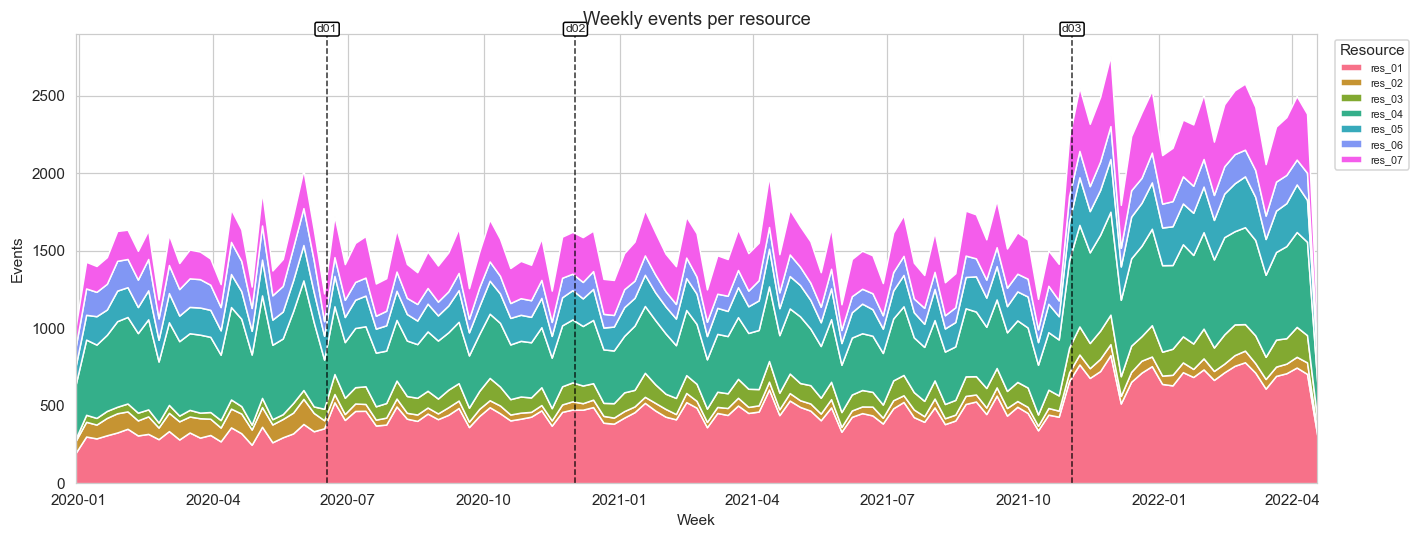

In [13]:
weekly_stack(drifts, "Weekly events per resource")

## Reassignment

Changes the dominant resource for one or more activities. Signal: the resource mix
for an affected activity shifts at the drift, and the resource \u00d7 activity counts
change before vs after.

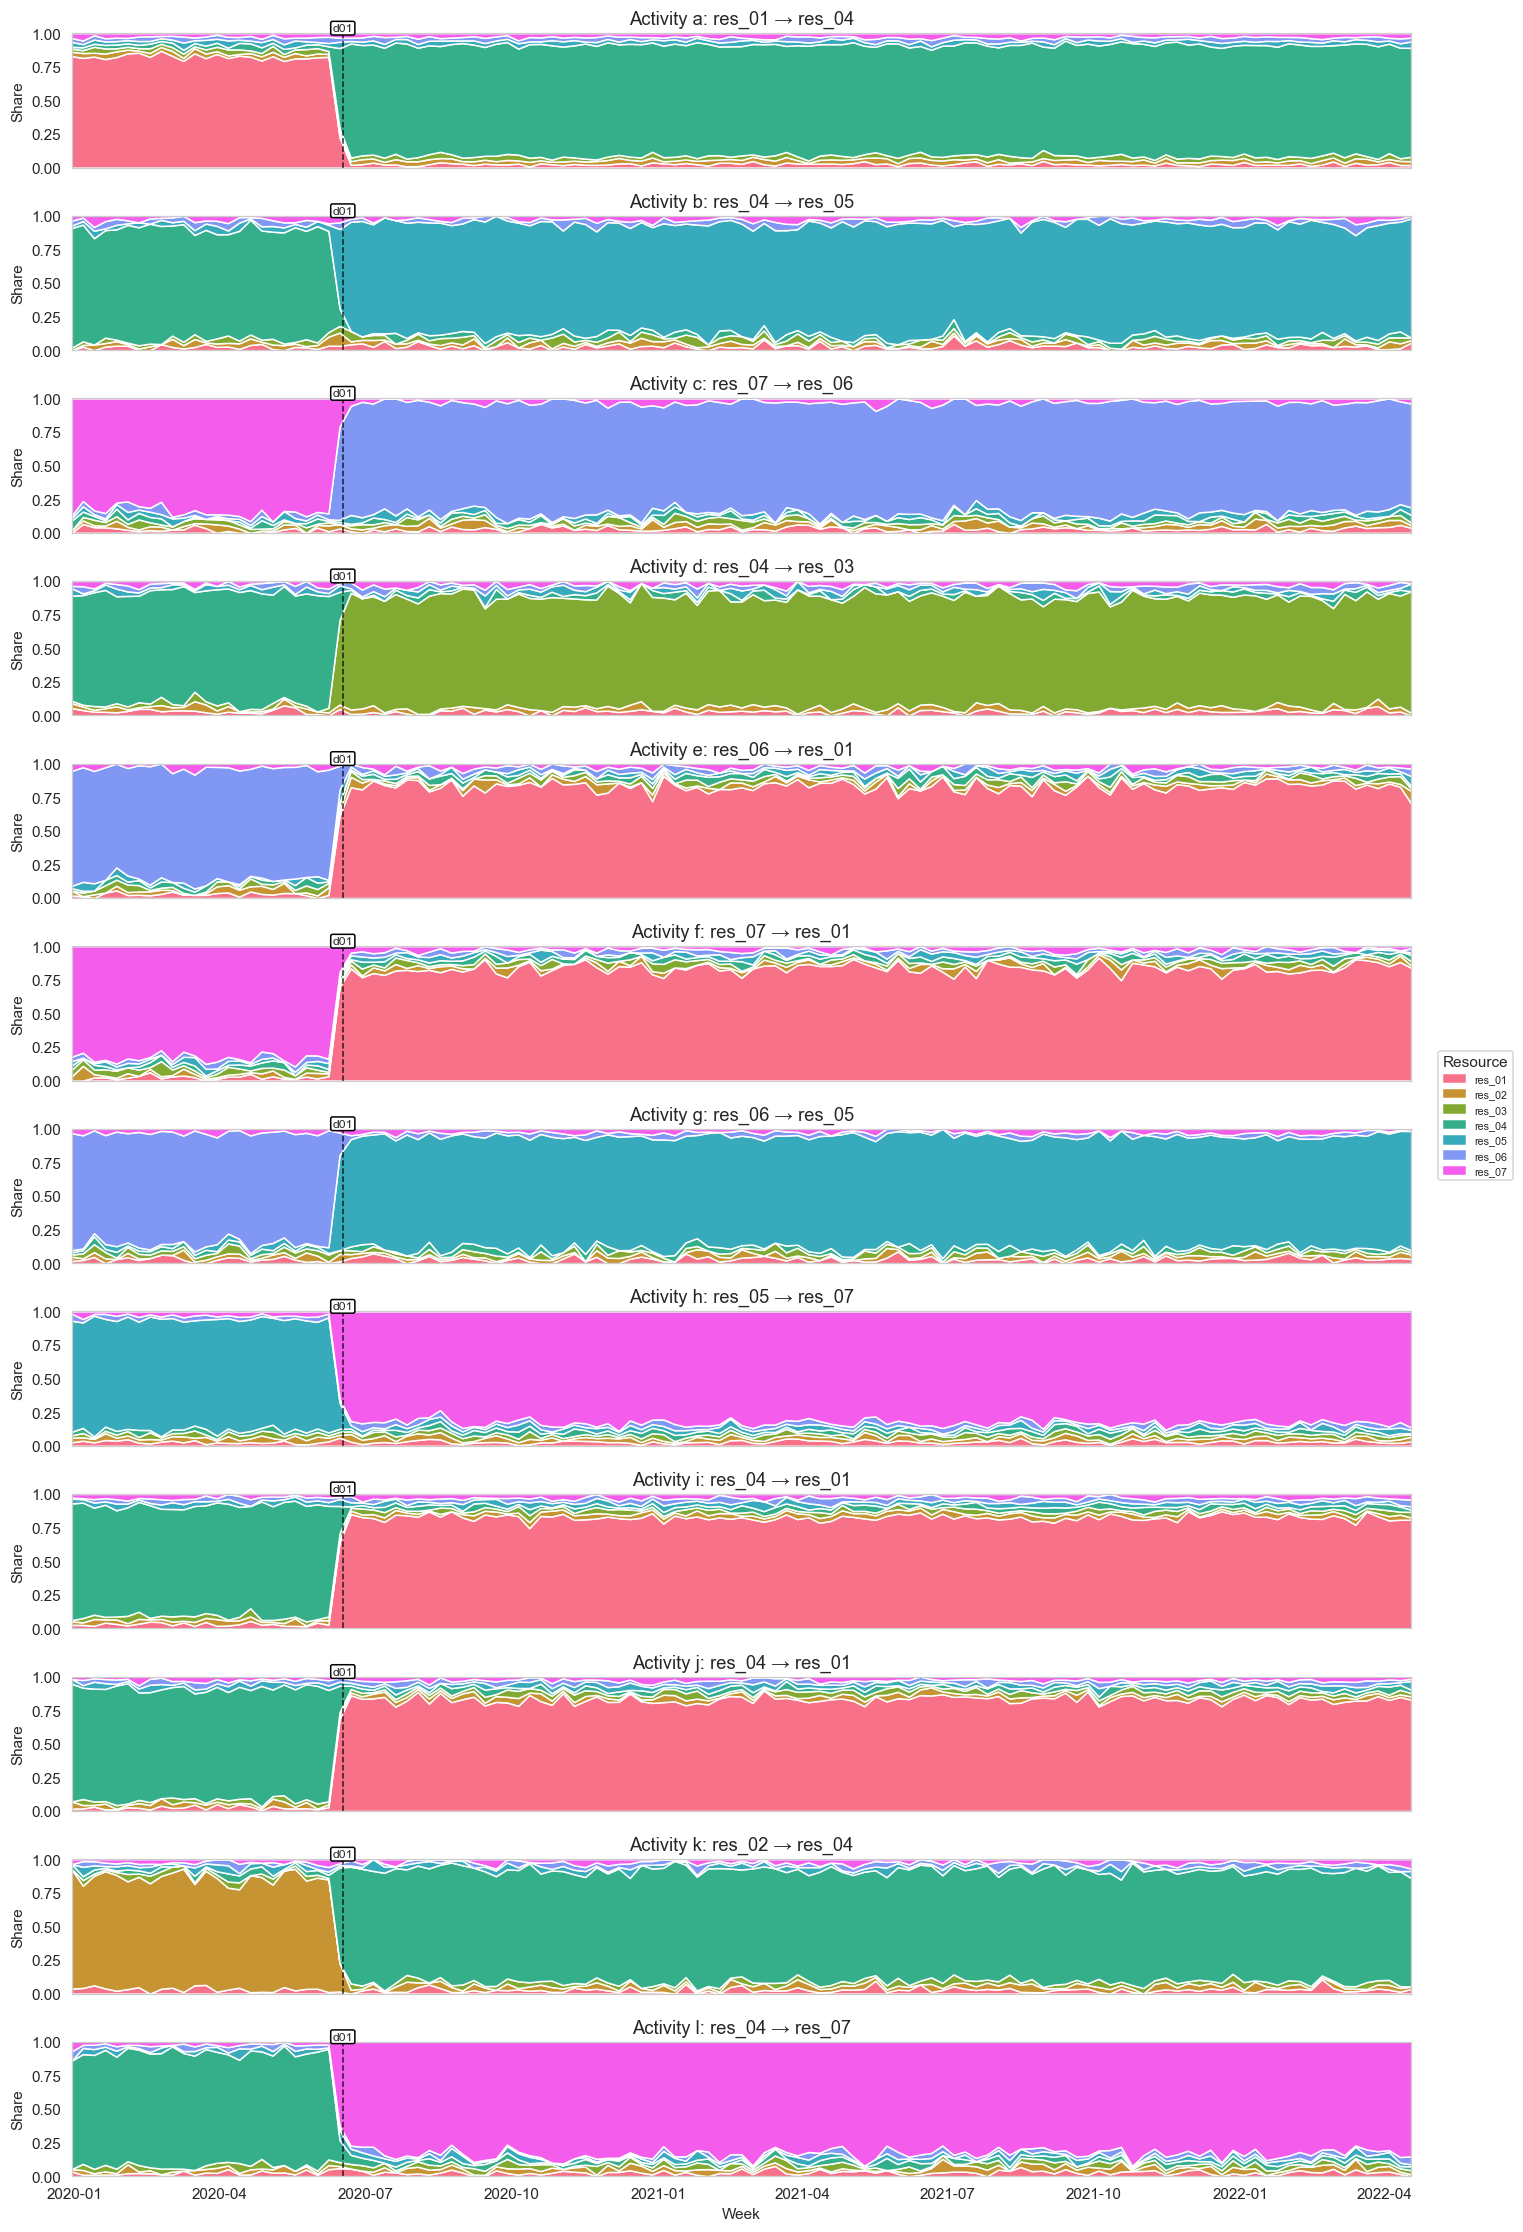

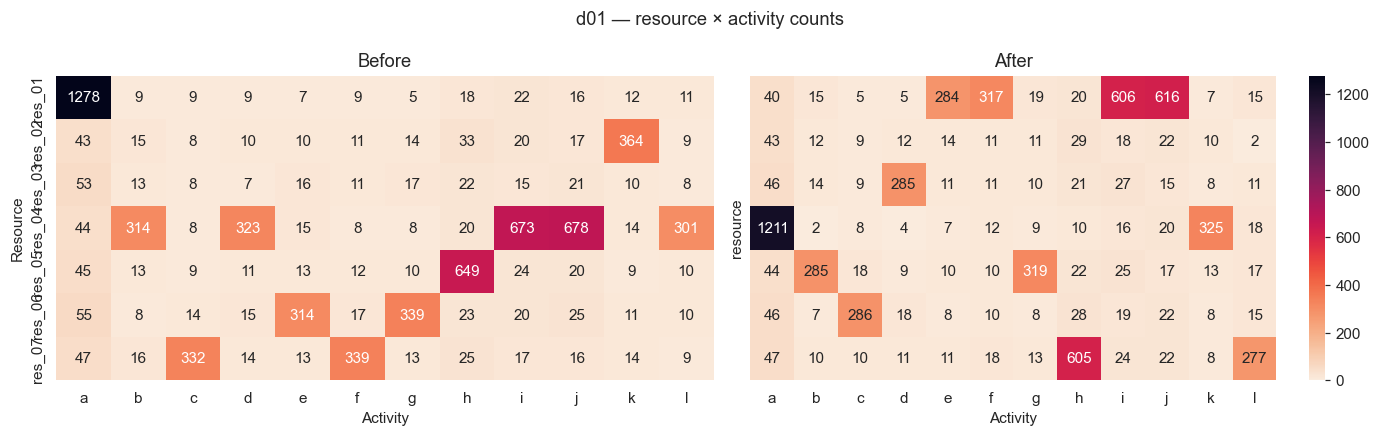

In [14]:
for _, d in of_type("reassignment").iterrows():
    before, after = d["changes"].get("dominant_before", {}), d["changes"].get("dominant_after", {})
    moved = [a for a in before if before.get(a) != after.get(a)] or activities

    fig, axes = plt.subplots(len(moved), 1, figsize=(13, max(3, 1.7 * len(moved))),
                             sharex=True, squeeze=False)
    for ax, a in zip(axes[:, 0], moved):
        w = (df[df["activity"].eq(a)].groupby(["week", "resource"]).size().unstack(fill_value=0)
             .reindex(columns=resources, fill_value=0).sort_index())
        w = w.div(w.sum(axis=1), axis=0).fillna(0)
        ax.stackplot(w.index, w.T.values, colors=[RES[r] for r in w.columns])
        ax.set(title=f"Activity {a}: {before.get(a, '?')} \u2192 {after.get(a, '?')}", ylabel="Share", ylim=(0, 1))
        ax.set_xlim(w.index.min(), w.index.max())
        mark_drifts(ax, one(d["id"]))
    axes[-1, 0].set_xlabel("Week")
    handles = [plt.Rectangle((0, 0), 1, 1, color=RES[r]) for r in resources]
    fig.legend(handles, resources, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=7, title="Resource")
    plt.tight_layout()
    plt.show()

    pre, post = pre_post(d["start"])
    res_activity_heatmaps(pre, post, f"{d['id']} \u2014 resource \u00d7 activity counts", moved)

## Duration

Scales the processing time of specific resources. Signal: the affected resources'
(outlined) mean event duration jumps at the drift; wait time is unaffected.

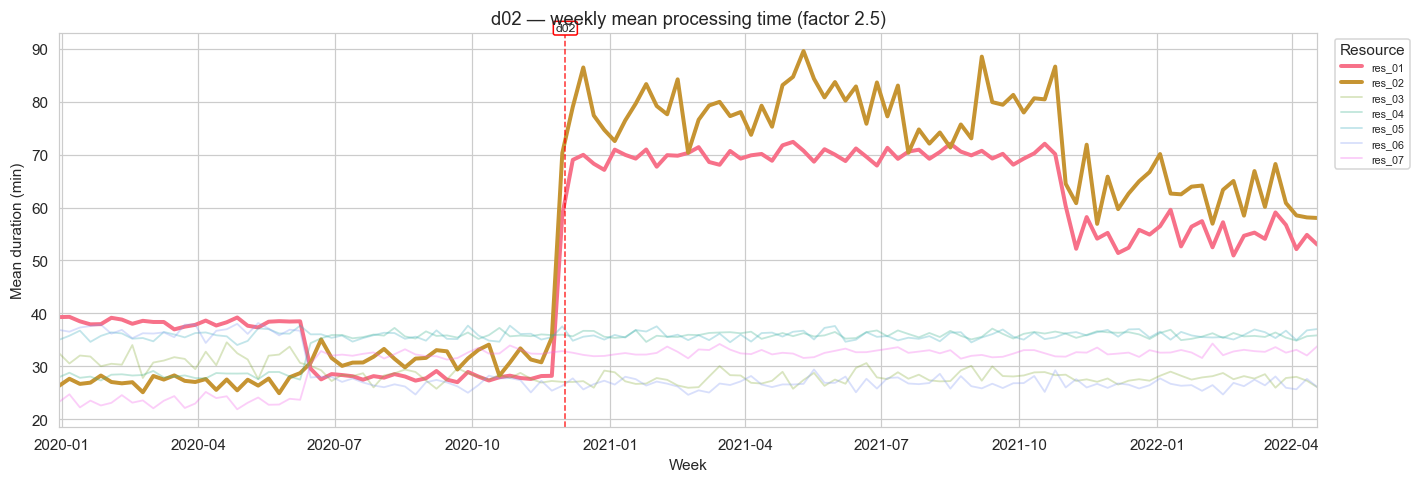

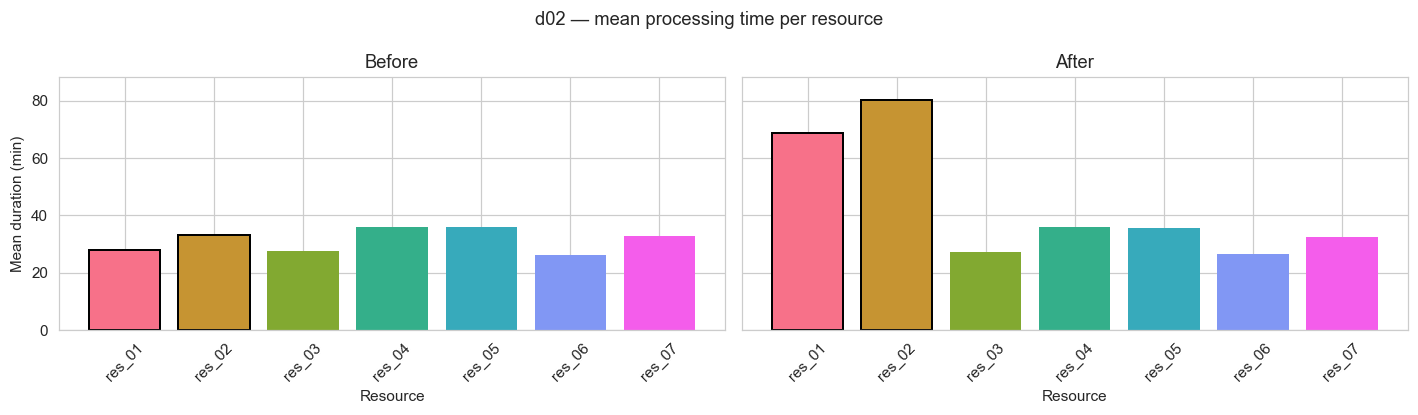

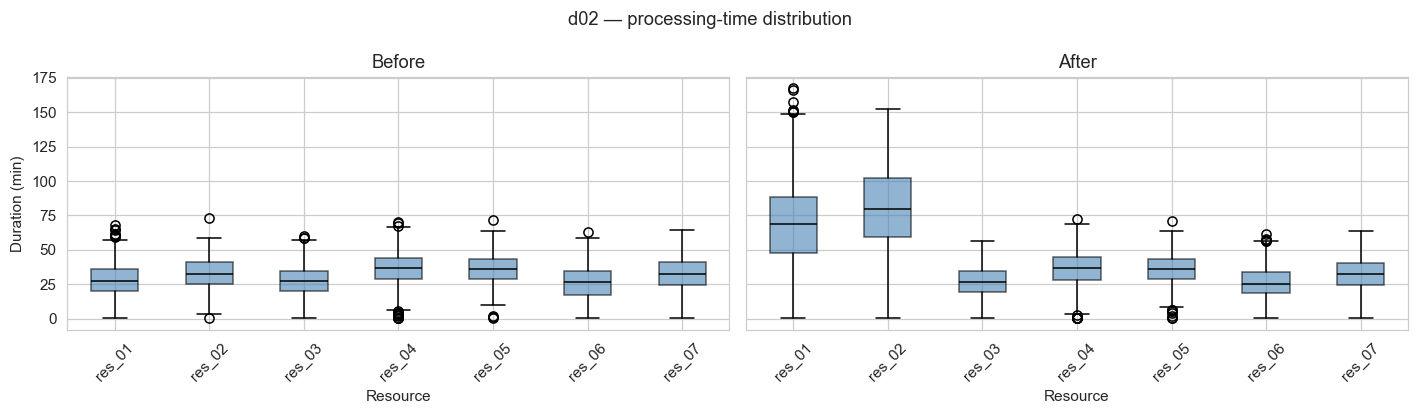

In [15]:
for _, d in of_type("duration").iterrows():
    hot = set(d["changes"].get("affected_resources", []))
    factor = d["changes"].get("factor", "?")
    metric_over_time("duration", f"{d['id']} \u2014 weekly mean processing time (factor {factor})",
                     "Mean duration (min)", one(d["id"]), highlight=hot)

    pre, post = pre_post(d["start"])
    bars(pre, post, lambda s: s.groupby("resource")["duration"].mean(),
         "Mean duration (min)", f"{d['id']} \u2014 mean processing time per resource", highlight=hot)

    fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
    for ax, sub, lbl in zip(axes, [pre, post], ["Before", "After"]):
        ax.boxplot([sub[sub["resource"].eq(r)]["duration"].dropna() for r in resources],
                   tick_labels=resources, patch_artist=True,
                   boxprops=dict(facecolor="steelblue", alpha=0.6), medianprops=dict(color="black"))
        ax.set(title=lbl, xlabel="Resource")
        ax.tick_params(axis="x", rotation=45)
    axes[0].set_ylabel("Duration (min)")
    fig.suptitle(f"{d['id']} \u2014 processing-time distribution")
    plt.tight_layout()
    plt.show()

## Pool size

Adds or removes active resources (durations scale the opposite way). Signal: the
count of distinct active resources changes, and load redistributes onto the
remaining/added resources (outlined).

In [16]:
active_week = df.groupby("week")["resource"].nunique()
for _, d in of_type("pool_size").iterrows():
    ch = d["changes"]
    fig, ax = plt.subplots(figsize=(13, 3.8))
    ax.fill_between(active_week.index, active_week.values, alpha=0.25, color="steelblue")
    ax.plot(active_week.index, active_week.values, marker="o", color="steelblue")
    ax.set(title=f"{d['id']} \u2014 distinct active resources per week "
                 f"({ch.get('old_pool_size', '?')} \u2192 {ch.get('new_pool_size', '?')})",
           xlabel="Week", ylabel="Active resources", ylim=(0, active_week.max() + 1))
    mark_drifts(ax, one(d["id"]), color="red")
    plt.tight_layout()
    plt.show()

    changed = set(ch.get("removed_resources", [])) | set(ch.get("added_resources", []))
    pre, post = pre_post(d["start"])
    bars(pre, post, lambda s: s["resource"].value_counts(), "Events",
         f"{d['id']} \u2014 events per resource", highlight=changed)
    bars(pre, post, lambda s: s.groupby("resource")["case_id"].nunique(), "Distinct cases",
         f"{d['id']} \u2014 distinct cases per resource", highlight=changed)

## Workload

Changes case volume after the drift by duplicating or dropping traces. Signal: the
number of events and cases handled per resource scales up or down together.

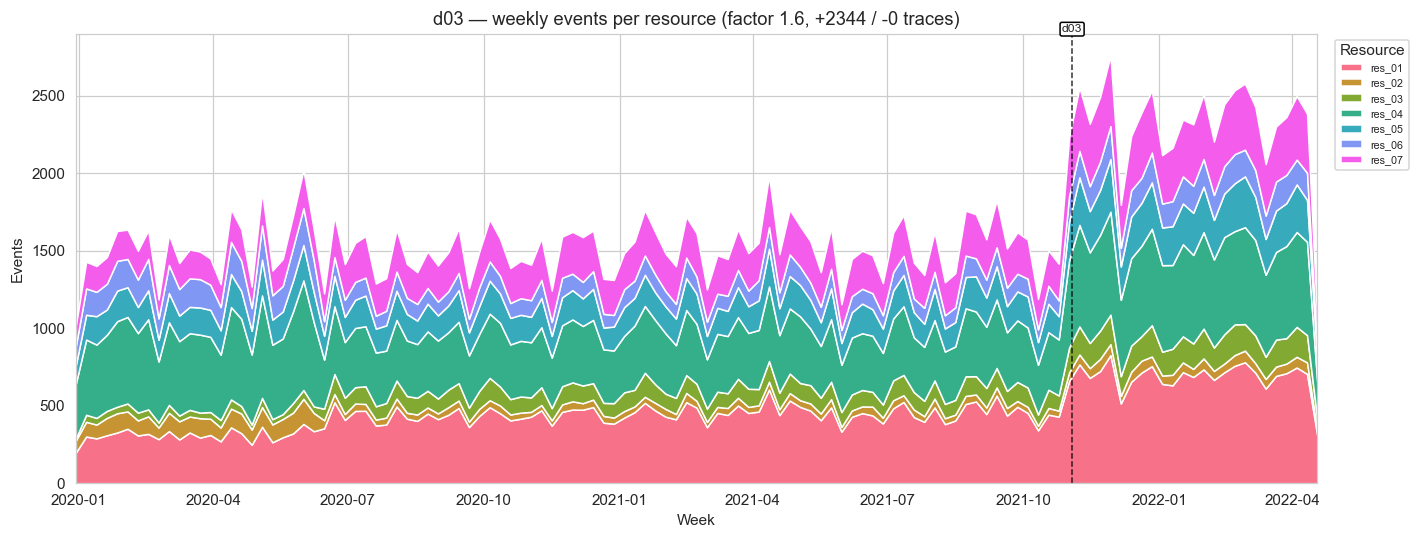

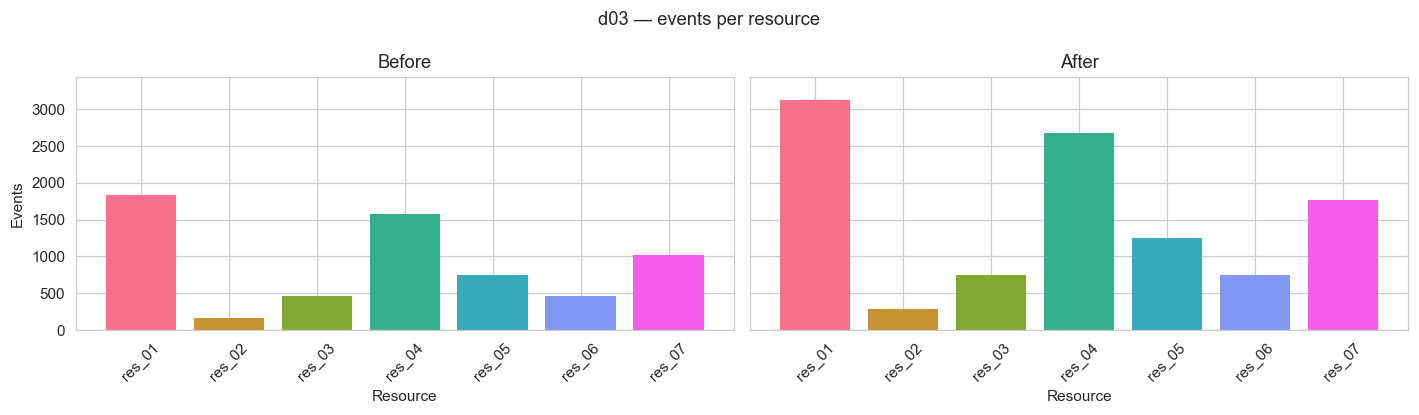

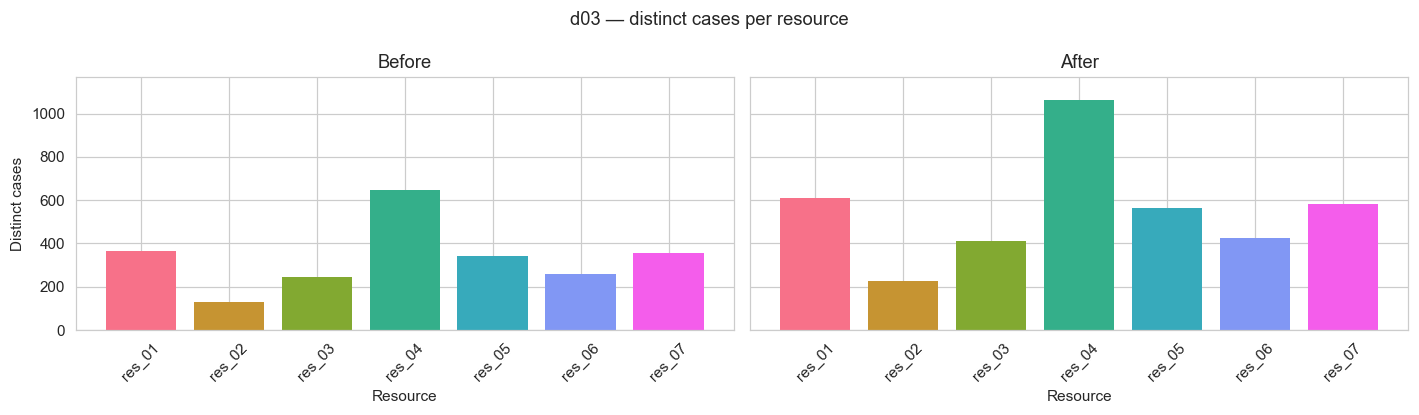

In [17]:
for _, d in of_type("workload").iterrows():
    ch = d["changes"]
    weekly_stack(one(d["id"]),
                 f"{d['id']} \u2014 weekly events per resource "
                 f"(factor {ch.get('workload_factor', '?')}, +{ch.get('added_traces', 0)} / -{ch.get('removed_traces', 0)} traces)")
    pre, post = pre_post(d["start"])
    bars(pre, post, lambda s: s["resource"].value_counts(), "Events",
         f"{d['id']} \u2014 events per resource")
    bars(pre, post, lambda s: s.groupby("resource")["case_id"].nunique(), "Distinct cases",
         f"{d['id']} \u2014 distinct cases per resource")